#**Chest X-Ray Classification**


---


##Project Goal

The goal of this project is to solve a multi-class image classification task using chest X-ray images:

*  ⁠Input: Chest X-ray image (224×224)
*  ⁠Output: One of three classes: Normal, Bacterial Pneumonia, or Viral Pneumonia
*  ⁠Dataset: Chest X-ray Pneumonia dataset (Kaggle)
*  ⁠Framework: TensorFlow / Keras

This project explores and compares different deep learning approaches for medical image classification.

We implement and evaluate three models:


1. Custom CNN – trained from scratch
2. EfficientNet (Transfer Learning) – pretrained model with fine-tuning
3. Patch-Based RNN – sequential modeling using image patches




   

#Project Setup and Data Acquisition
prepare our environment by importing the necessary libraries and downloading the Chest X-ray dataset directly from Kaggle.

Importing Keras and TensorFlow for model building.

Using kagglehub to fetch the latest version of the dataset.


In [ ]:
%%capture
!pip install ipython-autotime
%load_ext autotime

time: 398 µs (started: 2026-04-29 17:51:50 +00:00)


In [ ]:
%%capture
!pip install gdown

time: 4.39 s (started: 2026-04-30 18:17:06 +00:00)


In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import tensorflow as tf
import kagglehub
import gc
import gdown

from tensorflow import keras
from os import path
from tensorflow.keras import layers , models , optimizers , regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.utils import load_img, img_to_array
from sklearn import metrics
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split
from prompt_toolkit import history
from google.colab import files
from PIL import Image


time: 1.25 ms (started: 2026-04-30 18:17:11 +00:00)


##Download Dataset from kaggle

In [ ]:
dataset_path = kagglehub.dataset_download("paultimothymooney/chest-xray-pneumonia")

print(f"Dataset stored at: {dataset_path}")

Using Colab cache for faster access to the 'chest-xray-pneumonia' dataset.
Dataset stored at: /kaggle/input/chest-xray-pneumonia
time: 22.7 s (started: 2026-04-30 18:17:11 +00:00)


##Data Organisation & Labeling
The original dataset is divided into **Normal** and **Pneumonia** folders.
For the first, we divide **Pneumonia** folder to **Bacterial Pneumonia** and **Viral Pneumonia**.

**Process:**<br>
We will scan the file names in the Pneumonia directory.<br>
If the filename contains "**bacteria**", we'll classify it as **Bacterial**.<br>
If it contains "**virus**", we'll classify it as **Viral**.





In [ ]:
base_dir = dataset_path

def get_data_paths(subset):
    path = os.path.join(base_dir, 'chest_xray', subset)
    data = []
    for folder in ['NORMAL', 'PNEUMONIA']:
        folder_path = os.path.join(path, folder)
        for img_path in glob.glob(os.path.join(folder_path, '*.jpeg')):
            filename = os.path.basename(img_path).lower()
            if 'normal' in folder.lower():
                label = 'Normal'
            elif 'bacteria' in filename:
                label = 'Bacterial'
            elif 'virus' in filename:
                label = 'Viral'
            else:
                continue
            data.append((img_path, label))
    return pd.DataFrame(data, columns=['image_path', 'label'])


time: 971 µs (started: 2026-04-30 18:17:33 +00:00)


### Dataset Splitting Strategy

According to the project instructions, we were allowed to merge the original training and validation sets, while keeping the original test set unchanged.

We chose to combine the training and validation data in order to increase the amount of data available for learning. After merging, we created a new stratified split into training and validation sets. The stratified split ensures that the class distribution (Normal, Bacterial, Viral) remains balanced across both subsets.

The test set was not modified and was kept completely separate. This allows us to perform a fair and unbiased evaluation of the final models.

In [ ]:
orig_train_df = get_data_paths('train')
orig_val_df = get_data_paths('val')
test_df = get_data_paths('test')

full_train_df = pd.concat([orig_train_df, orig_val_df], axis=0).reset_index(drop=True)

train_df, val_df = train_test_split(
    full_train_df,
    test_size=0.20,
    random_state=42,
    stratify=full_train_df['label']
)

print(f"Combined data split into:/n {len(train_df)} Training and {len(val_df)} Validation samples.")
print(f"Test set remains at:/n {len(test_df)} samples.")

Combined data split into:/n 4185 Training and 1047 Validation samples.
Test set remains at:/n 624 samples.
time: 261 ms (started: 2026-04-30 18:17:33 +00:00)


###Dataset distribution

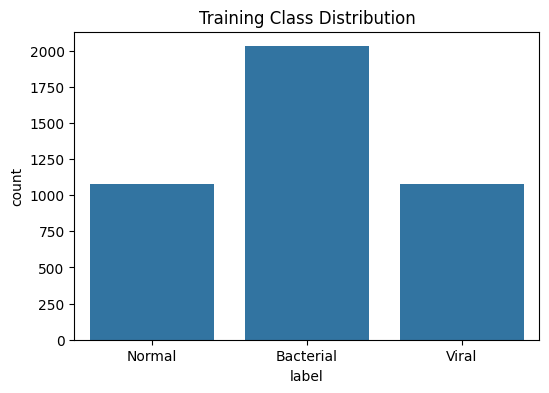

time: 137 ms (started: 2026-04-30 18:17:34 +00:00)


In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(data=train_df, x="label")

plt.title("Training Class Distribution")

plt.show()

##Functions

In [ ]:
def plot_history(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    # Accuracy Plot
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.title('Training and Validation Accuracy')
    plt.legend()

    # Loss Plot
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.title('Training and Validation Loss')
    plt.legend()
    plt.show()


def evaluate_model(model, generator, title):
    generator.reset()

    predictions = model.predict(generator, verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes
    class_labels = list(generator.class_indices.keys())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))


def final_test_results(model, generator, verbose=0):
    test_loss, test_acc = model.evaluate(generator, verbose=0)
    print("="*30)
    print(f" FINAL TEST RESULTS ")
    print("="*30)
    print(f"Test Loss:     {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc * 100:.2f}%") # Multiplying by 100 for percentage
    print("="*30)

    results = [test_acc, 1 - test_acc]
    labels = ['Success (Correct)', 'Failure (Incorrect)']

    plt.figure(figsize=(6, 4))
    plt.bar(labels, results, color=['green', 'red'], alpha=0.7)
    plt.ylabel('Proportion')
    plt.title(f'Overall Test Accuracy: {test_acc * 100:.2f}%')
    plt.ylim(0, 1) # Scale from 0 to 100%
    for i, v in enumerate(results):
        plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')
    plt.show()


def evaluate_rnn_model(model, X_test, y_test, title):
    predictions = model.predict(X_test, verbose=1)
    y_pred = np.argmax(predictions, axis=1)
    y_true = np.argmax(y_test, axis=1)

    class_labels = list(label_to_index.keys())

    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=class_labels, yticklabels=class_labels)
    plt.title(title)
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_true, y_pred, target_names=class_labels))



def final_test_results_rnn(X_test_patches , y_test_rnn, verbose=0):
    test_loss, test_acc = rnn_model.evaluate(X_test_patches, y_test_rnn, verbose=0)

    print("="*30)
    print(" FINAL TEST RESULTS ")
    print("="*30)
    print(f"Test Loss:     {test_loss:.4f}")
    print(f"Test Accuracy: {test_acc * 100:.2f}%")
    print("="*30)

    results = [test_acc, 1 - test_acc]
    labels = ['Success (Correct)', 'Failure (Incorrect)']

    plt.figure(figsize=(6, 4))
    plt.bar(labels, results, color=['green', 'red'], alpha=0.7)
    plt.ylabel('Proportion')
    plt.title(f'Overall Test Accuracy: {test_acc * 100:.2f}%')
    plt.ylim(0, 1) # Scale from 0 to 100%
    for i, v in enumerate(results):
        plt.text(i, v + 0.02, f"{v*100:.1f}%", ha='center', fontweight='bold')
    plt.show()

time: 4.59 ms (started: 2026-04-30 18:17:34 +00:00)


##Global Parameters

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
class_names = ['Bacterial', 'Normal', 'Viral']

time: 371 µs (started: 2026-04-30 18:17:34 +00:00)


#Connect to Google Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

DIR_A = '/content/drive/MyDrive/X-ray-Final_Project/A-Deep_Neural_Network'
DIR_B1 = '/content/drive/MyDrive/X-ray-Final_Project/B-Transfer_Learning_Model/Frozen-Backbone'
DIR_B2 = '/content/drive/MyDrive/X-ray-Final_Project/B-Transfer_Learning_Model/Fine-tuning'
DIR_C = '/content/drive/MyDrive/X-ray-Final_Project/C-Patch-Based_and_RNN'
DIR_COMPAR = '/content/drive/MyDrive/X-ray-Final_Project/Model-Comparison'

Mounted at /content/drive


#A

#Deep Neural Network
**Concept** <br>
In this section, we design and build our own Convolutional Neural Network (CNN) from scratch to classify the X-ray images into 3 categories.




##Data Preprocessing & Visualisation
Resizing: Standardizing all images to
224×224
 pixels.

Normalization: Scaling pixel values from [0, 255] to [0, 1] to help the model converge faster.

Data Augmentation: Since medical data is often limited, we apply mild augmentation techniques such as small rotations, shifts, and zoom (only on the training set) to improve generalization. The transformations are intentionally kept subtle, as aggressive changes (such as large rotations or horizontal flips) may distort anatomical structures in chest X-ray images and lead to unrealistic samples.
Data Generators: Using Keras ImageDataGenerator to feed the data in batches, saving memory.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=10,
    width_shift_range=0.05,
    height_shift_range=0.05,
    #shear_range=0.1,
    zoom_range=0.1,
    #horizontal_flip=True,
    fill_mode='nearest'
)

test_datagen = ImageDataGenerator(rescale=1./255)


time: 578 µs (started: 2026-04-29 16:26:35 +00:00)


##Data Generators
(Feeding the new split DataFrames into the generators)


In [ ]:
train_generator = train_datagen.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = test_datagen.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

test_generator = test_datagen.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    shuffle=False
)

Found 4185 validated image filenames belonging to 3 classes.
Found 1047 validated image filenames belonging to 3 classes.
Found 624 validated image filenames belonging to 3 classes.
time: 5.78 s (started: 2026-04-29 16:26:35 +00:00)


##Visualize Images

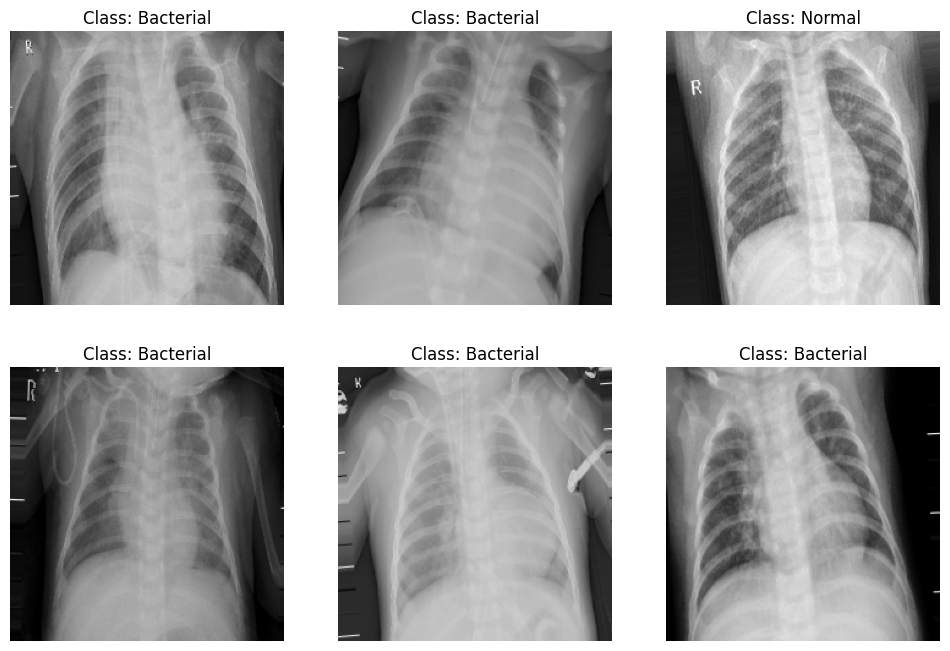

time: 5.34 s (started: 2026-04-29 16:26:41 +00:00)


In [ ]:
plt.figure(figsize=(12, 8))
for i in range(6):
  img, label = next(train_generator)
  plt.subplot(2, 3, i + 1)
  plt.imshow(img[0])
  plt.title(f"Class: {list(train_generator.class_indices.keys())[np.argmax(label[0])]}")
  plt.axis('off')
plt.show()

##Custom Deep Neural Network

**Architecture Design:**



*   Convolutional Layers (Conv2D): To extract spatial features like edges and lung opacities. We'll use 3×3 filters.
*   Batch Normalization: To stabilize and speed up the training process.
* MaxPooling: To reduce the spatial dimensions and computational load.
* Dropout: To prevent overfitting (crucial since medical datasets are often small).
* Output Layer: A Dense layer with 3 neurons and a Softmax activation function for multi-class classification.




**Loss & Optimizer:**

* Loss: categorical_crossentropy (standard for 3+ classes).

* Optimizer: Adam (with a tuned learning rate).











In [ ]:
tf.keras.backend.clear_session()

model = models.Sequential([
   layers.Conv2D(32, kernel_size=3, activation='relu', padding='same', input_shape=(224, 224, 3)),
   layers.BatchNormalization(),
   layers.MaxPooling2D(pool_size=2),

   layers.Conv2D(64, kernel_size=3, activation='relu', padding='same'),
   layers.BatchNormalization(),
   layers.MaxPooling2D(pool_size=2),

   layers.Conv2D(128, kernel_size=3, activation='relu', padding='same'),
   layers.BatchNormalization(),
   layers.MaxPooling2D(2),

   #layers.Conv2D(256, kernel_size=3, activation='relu', padding='same'),
   #layers.BatchNormalization(),
   #layers.MaxPooling2D(pool_size=2),

   layers.Flatten(),

   layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
   layers.Dropout(0.5),
   layers.Dense(3, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


time: 2.84 s (started: 2026-04-29 16:26:46 +00:00)


In [ ]:
model.compile(
    optimizer = optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics = ['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 3)              │           771 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,785,283 (98.36 MB)

 Trainable params: 25,784,835 (98.36 MB)

 Non-trainable params: 448 (1.75 KB)

time: 26.2 ms (started: 2026-04-29 16:26:49 +00:00)


## Training the Custom CNN
To achieve the best results and avoid overfitting, we implement several Keras Callbacks:

* EarlyStopping: Stops training if the validation loss doesn't improve for 5 consecutive epochs. This prevents the model from "memorizing" the training data (Overfitting).

* ReduceLROnPlateau: If the learning stalls, this will automatically reduce the learning rate by a factor (e.g., 0.2), allowing the model to make smaller, more precise "steps" towards the optimum.

* ModelCheckpoint: Saves only the best version of our model (the one with the lowest validation loss).

Since the dataset is imbalanced across the three classes, relying on standard accuracy alone may lead to biased predictions toward the majority class. To address this, we compute class weights based on the training data and incorporate them during training. This ensures that errors on underrepresented classes (such as Viral pneumonia) are penalized more, encouraging the model to learn a more balanced decision boundary.

In [ ]:
weight = compute_class_weight(
    class_weight = 'balanced',
    classes = np.unique(train_generator.classes),
    y = train_generator.classes
)

class_weights = dict(enumerate(weight))

callbacks = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.2, patience=2, min_lr=1e-5, verbose=1),
    ModelCheckpoint(os.path.join(DIR_A, 'best_cnn_model.keras'), monitor='val_accuracy', save_best_only=True, verbose=1)
]

time: 3.66 ms (started: 2026-04-29 16:26:49 +00:00)


In [ ]:
history = model.fit(
    train_generator,
    validation_data = val_generator,
    epochs = 20,
    callbacks = callbacks,
    class_weight = class_weights
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 812ms/step - accuracy: 0.5632 - loss: 2.5452
Epoch 1: val_accuracy improved from None to 0.48520, saving model to /content/drive/MyDrive/X-ray-Final_Project/A-Deep_Neural_Network/best_cnn_model.keras

Epoch 1: finished saving model to /content/drive/MyDrive/X-ray-Final_Project/A-Deep_Neural_Network/best_cnn_model.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 139s 971ms/step - accuracy: 0.6356 - loss: 1.3379 - val_accuracy: 0.4852 - val_loss: 5.5390 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 601ms/step - accuracy: 0.6706 - loss: 0.7922
Epoch 2: val_accuracy did not improve from 0.48520
131/131 ━━━━━━━━━━━━━━━━━━━━ 89s 677ms/step - accuracy: 0.6808 - loss: 0.7800 - val_accuracy: 0.4852 - val_loss: 2.6509 - learning_rate: 1.0000e-04
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 594ms/step - accuracy: 0.7279 - loss: 0.7446
Epoch 3: val_accuracy improved from 0.48520 to 0.69436, saving model to /content/drive/MyDrive/X-ray-Final_Proje

###Savings weight and history

In [ ]:
model.save_weights(os.path.join(DIR_A,'winning_cnn_weights.weights.h5'))
model.save(os.path.join(DIR_A,'cnn_model.keras'))
history_CNN_df = pd.DataFrame(history.history)
history_CNN_df.to_csv(os.path.join(DIR_A,'history_cnn.csv'), index=False)


time: 1.96 s (started: 2026-04-29 16:52:48 +00:00)


###Visualizing Results

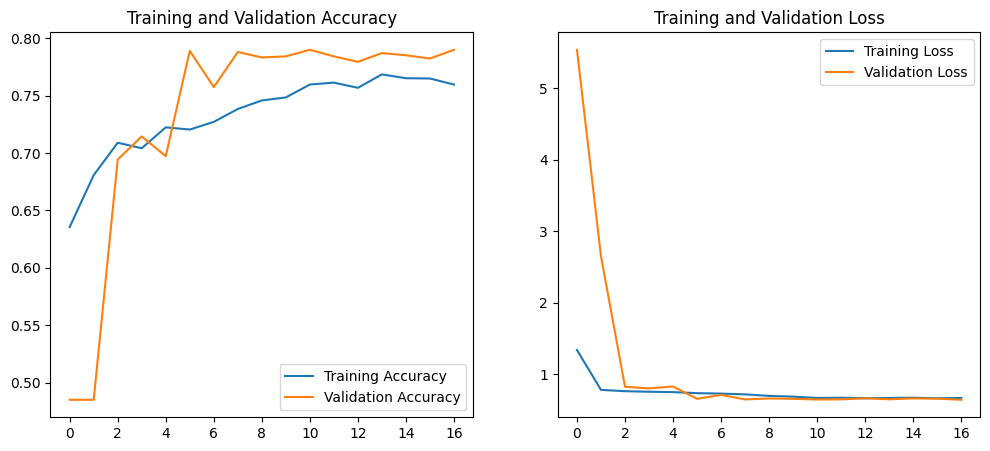

time: 263 ms (started: 2026-04-29 16:52:50 +00:00)


In [ ]:
# Plotting Accuracy and Loss
plot_history(history)

###Model Evaluation on Test Set
Now we evaluate our custom model using the Test Set. This is the most critical part of the project.

**Metrics used:**

* Confusion Matrix: Shows exactly how many images were correctly classified and where the model "got confused" (e.g., mistaking Bacterial for Viral).

* Classification Report: Provides Precision, Recall, and F1-Score for each class.

  * Crucial note: In medical diagnosis, high Recall for pneumonia is vital because we don't want to miss a sick patient (False Negative).

20/20 ━━━━━━━━━━━━━━━━━━━━ 10s 490ms/step


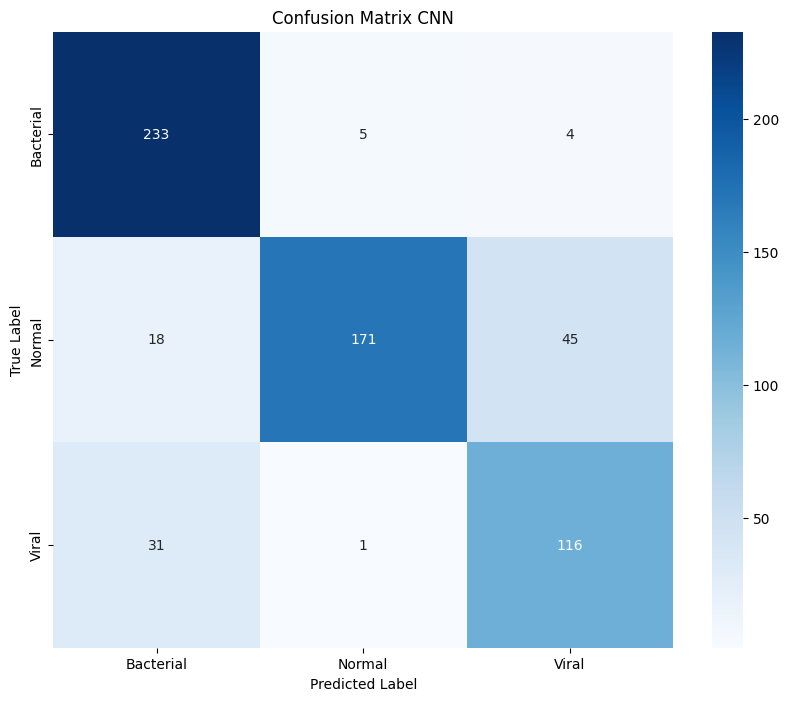


Classification Report:
              precision    recall  f1-score   support

   Bacterial       0.83      0.96      0.89       242
      Normal       0.97      0.73      0.83       234
       Viral       0.70      0.78      0.74       148

    accuracy                           0.83       624
   macro avg       0.83      0.83      0.82       624
weighted avg       0.85      0.83      0.83       624

time: 11.9 s (started: 2026-04-29 16:52:50 +00:00)


In [ ]:
evaluate_model(model, test_generator, 'Confusion Matrix CNN')

 FINAL TEST RESULTS 
Test Loss:     0.7763
Test Accuracy: 83.33%


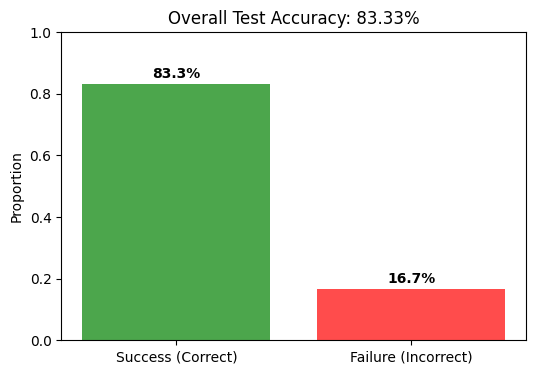

time: 8.32 s (started: 2026-04-29 16:53:02 +00:00)


In [ ]:
final_test_results(model, test_generator, 0)

#B

#Transfer Learning using EfficientNetB0
**Concept** <br>
In this section, we use Transfer Learning with a pre-trained model (EfficientNetB0) trained on ImageNet. The original ImageNet dataset contains natural RGB images, while our task involves medical chest X-ray images, creating a domain shift between the source and target domains.

Despite this difference, early layers of convolutional neural networks learn general visual features such as edges, textures, and shapes, which can still be useful for X-ray images. Therefore, instead of training a model from scratch, we leverage these learned features and adapt them to our task by training a new classification head for the three classes: Normal, Viral, and Bacterial.

##Data Preprocessing for Transfer Learning

In [ ]:
train_datagen_b = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=6,
    width_shift_range=0.03,
    height_shift_range=0.03,
    zoom_range=0.05,
    fill_mode='nearest'
)

test_datagen_b = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

time: 637 µs (started: 2026-04-02 10:58:23 +00:00)


##Data Generators

In [ ]:
train_generator_b = train_datagen_b.flow_from_dataframe(
    train_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_names
)

val_generator_b = test_datagen_b.flow_from_dataframe(
    val_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_names,
    shuffle=False
)

test_generator_b = test_datagen_b.flow_from_dataframe(
    test_df,
    x_col='image_path',
    y_col='label',
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=class_names,
    shuffle=False
)

Found 4185 validated image filenames belonging to 3 classes.
Found 1047 validated image filenames belonging to 3 classes.
Found 624 validated image filenames belonging to 3 classes.
time: 2.67 s (started: 2026-04-02 10:58:23 +00:00)


# Training Strategy: Frozen Backbone vs Fine-Tuning

We follow a two-stage training strategy commonly used in transfer learning.

In the first stage, we freeze all layers of the pre-trained EfficientNet backbone and train only a new classification head. This allows the model to adapt to the new task without modifying the learned feature representations.

In the second stage, we partially unfreeze the upper layers of the backbone and fine-tune them using a smaller learning rate. The higher layers are more task-specific, so fine-tuning them helps the model better adapt to the X-ray domain while preserving useful low-level features learned from ImageNet.

##Phase 1: Training with Frozen Backbone

###Building the Transfer Learning Model

In [ ]:
tf.keras.backend.clear_session()

base_model = EfficientNetB0(
    weights='imagenet',
    include_top=False,
    input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3)
)
base_model.trainable = False #freezing all layers

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
time: 2.58 s (started: 2026-04-02 10:58:26 +00:00)


In [ ]:
tl_model = models.Sequential([
    base_model,

    layers.GlobalAveragePooling2D(),

    layers.BatchNormalization(),

    layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.5),

    layers.Dense(128, activation='relu', kernel_regularizer=regularizers.l2(1e-4)),
    layers.Dropout(0.3),

    layers.Dense(3, activation='softmax')
])

time: 58.9 ms (started: 2026-04-02 10:58:28 +00:00)


In [ ]:
tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

time: 13.8 ms (started: 2026-04-02 10:58:28 +00:00)


##Training Monitoring

In [ ]:
weight_b = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator_b.classes),
    y=train_generator_b.classes
)

class_weights_b = dict(enumerate(weight_b))

callbacks_b1 = [
    EarlyStopping(monitor='val_accuracy',mode='max', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy',mode='max', factor=0.2, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(DIR_B1,'best_transfer_frozen.keras'), monitor='val_accuracy',mode='max', save_best_only=True, verbose=1)
]

time: 4.58 ms (started: 2026-04-02 10:58:28 +00:00)


In [ ]:
history_tl_frozen = tl_model.fit(
    train_generator_b,
    epochs=20,
    validation_data=val_generator_b,
    class_weight=class_weights_b,
    callbacks=callbacks_b1,
    verbose=1
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 726ms/step - accuracy: 0.5222 - loss: 1.2646
Epoch 1: val_accuracy improved from None to 0.68290, saving model to /content/drive/MyDrive/X-ray-Final_Project/B-Transfer_Learning_Model/Frozen-Backbone/best_transfer_frozen.keras

Epoch 1: finished saving model to /content/drive/MyDrive/X-ray-Final_Project/B-Transfer_Learning_Model/Frozen-Backbone/best_transfer_frozen.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 144s 928ms/step - accuracy: 0.5740 - loss: 1.1497 - val_accuracy: 0.6829 - val_loss: 0.8822 - learning_rate: 1.0000e-04
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 638ms/step - accuracy: 0.6516 - loss: 0.9631
Epoch 2: val_accuracy improved from 0.68290 to 0.71442, saving model to /content/drive/MyDrive/X-ray-Final_Project/B-Transfer_Learning_Model/Frozen-Backbone/best_transfer_frozen.keras

Epoch 2: finished saving model to /content/drive/MyDrive/X-ray-Final_Project/B-Transfer_Learning_Model/Frozen-Backbone/best_transfer_frozen.keras
131/131 ━━━━━━━━

###Savings weight and history

In [ ]:
tl_model.save_weights(os.path.join(DIR_B1,'frozen_backbone_weights.weights.h5'))
tl_model.save(os.path.join(DIR_B1,'frozen_backbone_model.keras'))
history_frozen_df = pd.DataFrame(history_tl_frozen.history)
history_frozen_df.to_csv(os.path.join(DIR_B1,'history_frozen.csv'), index=False)

time: 4.14 s (started: 2026-04-02 11:21:31 +00:00)


###Visualizing Results

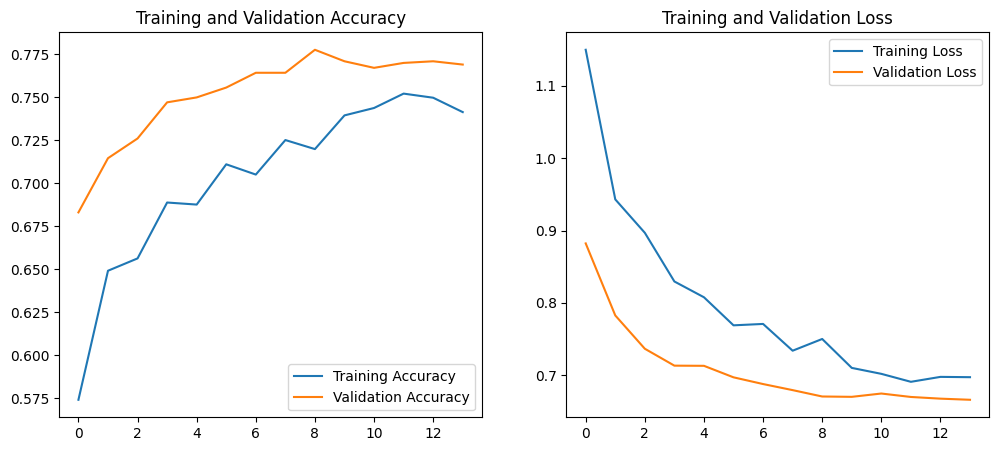

time: 1.02 s (started: 2026-04-02 11:21:36 +00:00)


In [ ]:
plot_history(history_tl_frozen)

20/20 ━━━━━━━━━━━━━━━━━━━━ 20s 622ms/step


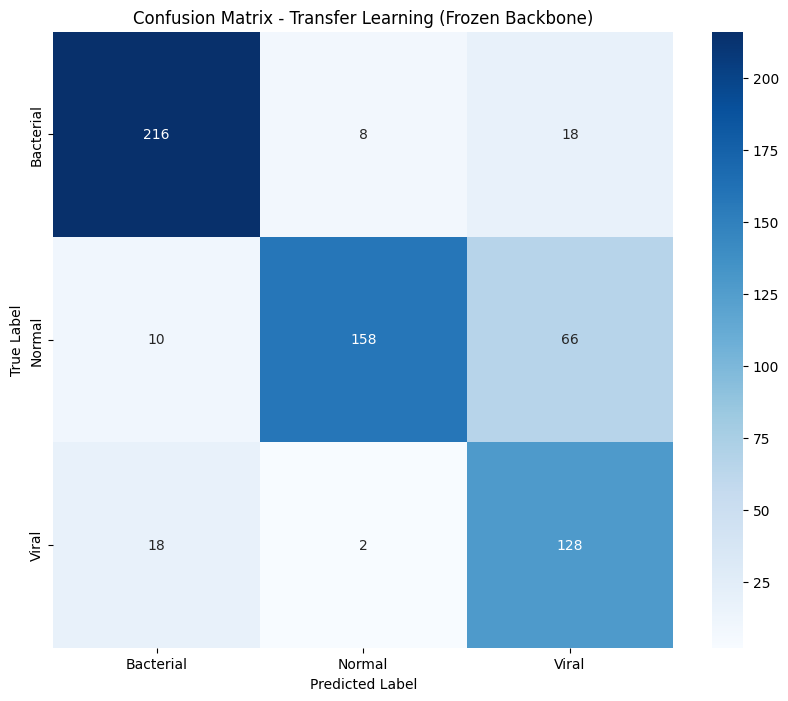


Classification Report:
              precision    recall  f1-score   support

   Bacterial       0.89      0.89      0.89       242
      Normal       0.94      0.68      0.79       234
       Viral       0.60      0.86      0.71       148

    accuracy                           0.80       624
   macro avg       0.81      0.81      0.80       624
weighted avg       0.84      0.80      0.81       624

time: 21 s (started: 2026-04-02 11:21:37 +00:00)


In [ ]:
evaluate_model(tl_model, test_generator_b, 'Confusion Matrix - Transfer Learning (Frozen Backbone)')

 FINAL TEST RESULTS 
Test Loss:     0.6852
Test Accuracy: 80.45%


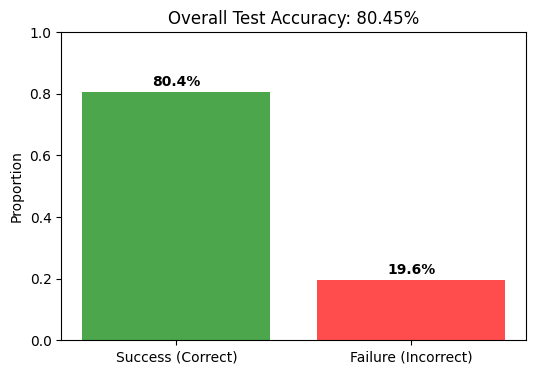

time: 11.4 s (started: 2026-04-02 11:21:58 +00:00)


In [ ]:
final_test_results(tl_model, test_generator_b, 0)

#Phase 2: Partial Fine-tuning

In [ ]:
tl_model = keras.models.load_model(os.path.join(DIR_B1, 'frozen_backbone_model.keras'))
base_model = tl_model.layers[0]

base_model.trainable = True

for layer in base_model.layers[:-50]: # need to do equ - 3,20,50,100,120
    layer.trainable = False
for layer in base_model.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

tl_model.compile(
    optimizer=optimizers.Adam(learning_rate=3e-6),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

time: 1.38 s (started: 2026-04-02 13:32:31 +00:00)


##Training Monitoring

In [ ]:
callbacks_b2 = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.2, patience=2, min_lr=1e-7, verbose=1),
    ModelCheckpoint(os.path.join(DIR_B2,'best_transfer_finetune.keras'), monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
]

time: 777 µs (started: 2026-04-02 13:32:32 +00:00)


In [ ]:
history_tl_finetune = tl_model.fit(
    train_generator_b,
    epochs=20,
    validation_data=val_generator_b,
    class_weight=class_weights_b,
    callbacks=callbacks_b2,
    verbose=1
)

Epoch 1/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 758ms/step - accuracy: 0.7274 - loss: 0.7148
Epoch 1: val_accuracy improved from None to 0.77937, saving model to /content/drive/MyDrive/X-ray-Final_Project/B-Transfer_Learning_Model/Fine-tuning/best_transfer_finetune.keras

Epoch 1: finished saving model to /content/drive/MyDrive/X-ray-Final_Project/B-Transfer_Learning_Model/Fine-tuning/best_transfer_finetune.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 152s 943ms/step - accuracy: 0.7286 - loss: 0.7204 - val_accuracy: 0.7794 - val_loss: 0.6655 - learning_rate: 3.0000e-06
Epoch 2/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 669ms/step - accuracy: 0.7263 - loss: 0.7247
Epoch 2: val_accuracy did not improve from 0.77937
131/131 ━━━━━━━━━━━━━━━━━━━━ 98s 752ms/step - accuracy: 0.7295 - loss: 0.7138 - val_accuracy: 0.7765 - val_loss: 0.6685 - learning_rate: 3.0000e-06
Epoch 3/20
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 658ms/step - accuracy: 0.7309 - loss: 0.7180
Epoch 3: ReduceLROnPlateau reducing learning rate to 6.000000212

###Savings weight and history

In [ ]:
tl_model.save_weights(os.path.join(DIR_B2,'finetuned_weight.weights.h5'))
tl_model.save(os.path.join(DIR_B2,'finetuned_model.keras'))
history_finetune_df = pd.DataFrame(history_tl_finetune.history)
history_finetune_df.to_csv(os.path.join(DIR_B2,'history_finetune.csv'), index=False)

time: 1.8 s (started: 2026-04-02 13:44:52 +00:00)


###Visualizing Results

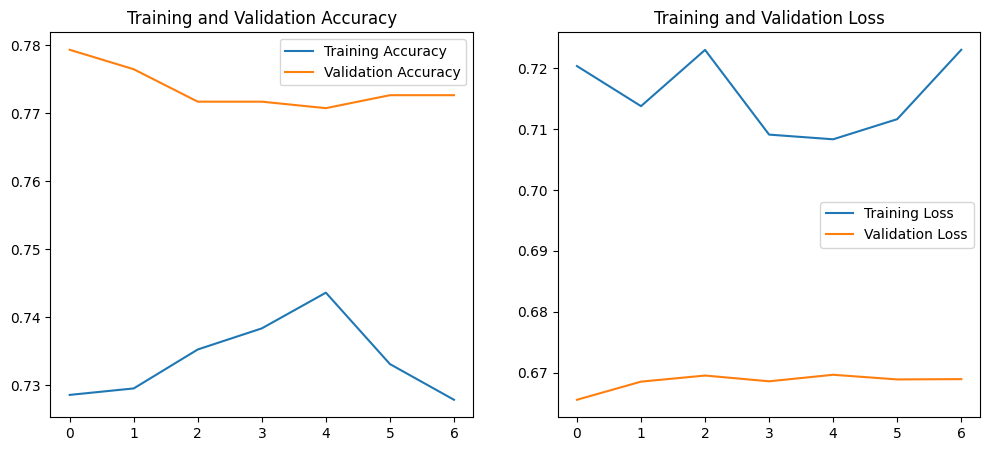

time: 244 ms (started: 2026-04-02 13:44:54 +00:00)


In [ ]:
plot_history(history_tl_finetune)

20/20 ━━━━━━━━━━━━━━━━━━━━ 23s 761ms/step


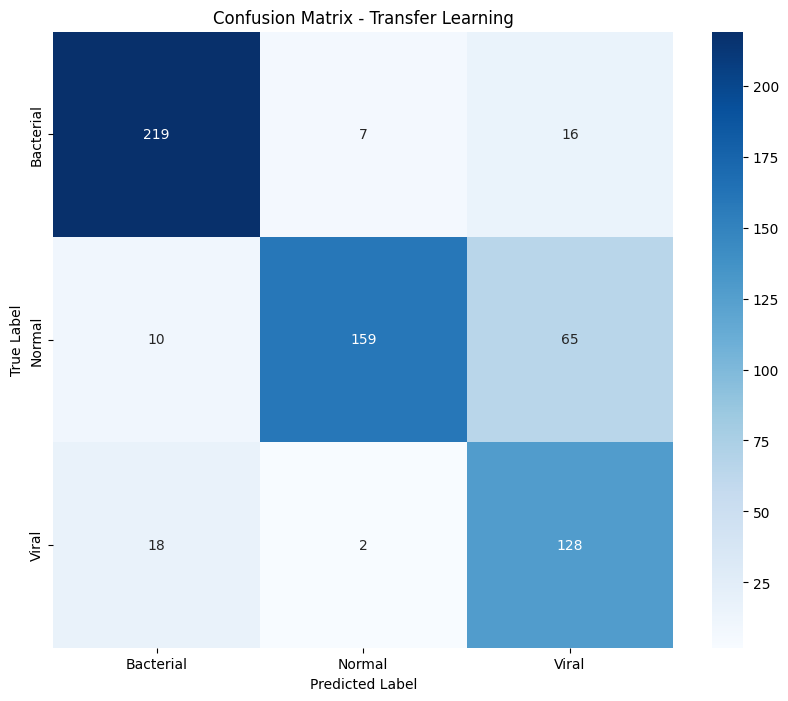


Classification Report:
              precision    recall  f1-score   support

   Bacterial       0.89      0.90      0.90       242
      Normal       0.95      0.68      0.79       234
       Viral       0.61      0.86      0.72       148

    accuracy                           0.81       624
   macro avg       0.82      0.82      0.80       624
weighted avg       0.84      0.81      0.81       624

time: 23.8 s (started: 2026-04-02 13:44:54 +00:00)


In [ ]:
evaluate_model(tl_model, test_generator_b, 'Confusion Matrix - Transfer Learning')

 FINAL TEST RESULTS 
Test Loss:     0.6851
Test Accuracy: 81.09%


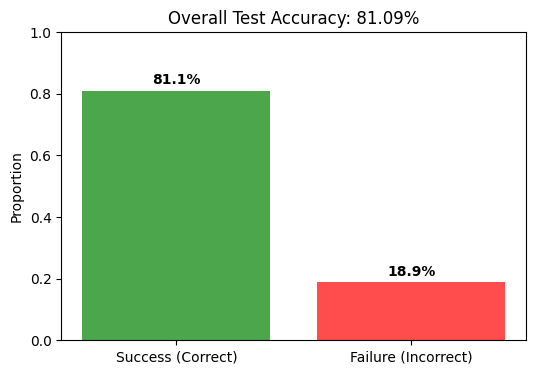

time: 11.4 s (started: 2026-04-02 13:45:18 +00:00)


In [ ]:
final_test_results(tl_model, test_generator_b, 0)

#C









#Patch-Based Image Representation using RNN

**Concept** <br>
In this section, instead of treating the image only as a 2D grid, we represent it as a sequence of patches. Each image is divided into small fixed-size patches, and each patch is flattened into a vector. Each patch vector is then treated as one step in a sequence.

This approach is inspired by recent vision methods that represent images as collections of tokens. In our implementation, the patch sequence is processed using a Bidirectional GRU, which allows the model to read the patch sequence in both directions and learn dependencies between different regions of the image.

This experiment allows us to compare traditional convolution-based models with a sequential representation of images.

**Pipeline:** <br>
Image -> Patches -> Sequence -> Bidirectional GRU -> Dense Layers -> Classification

##Loading Images for the RNN Pipeline
Since the RNN model requires array-based input, we load the images directly from the DataFrames and convert them into NumPy arrays.
Each image is resized to 224×224 and normalized to the range [0,1].


##Loading Images for the RNN Pipeline
Since the RNN model requires array-based input, we load the images directly from the DataFrames and convert them into NumPy arrays.
Each image is resized to 224×224 and normalized to the range [0,1].

In [ ]:
PATCH_SIZE = 16
NUM_CLASSES = 3

label_to_index = train_generator.class_indices
index_to_label = {v: k for k, v in label_to_index.items()}

def load_images_from_dataframe(df, target_size=IMG_SIZE):
    images = []
    labels = []

    for _, row in df.iterrows():
        img = keras.utils.load_img(row['image_path'], color_mode='grayscale', target_size=target_size)
        img = keras.utils.img_to_array(img)
        img = img / 255.0

        images.append(img)
        labels.append(label_to_index[row['label']]) #vec of class label e.g. [1 , 0 , 2 , 2 , 1 ,.....]

    X = np.array(images, dtype=np.float32)
    y = keras.utils.to_categorical(labels, num_classes=NUM_CLASSES)  #one hot encoding
    '''
    e.g.
    0 -> [1, 0, 0]
    1 -> [0, 1, 0]
    2 -> [0, 0, 1]
    '''

    return X, y

X_train_rnn, y_train_rnn = load_images_from_dataframe(train_df)
X_val_rnn, y_val_rnn = load_images_from_dataframe(val_df)
X_test_rnn, y_test_rnn = load_images_from_dataframe(test_df)

print("X_train_rnn shape:", X_train_rnn.shape)
print("y_train_rnn shape:", y_train_rnn.shape)
print("X_val_rnn shape:", X_val_rnn.shape)
print("y_val_rnn shape:", y_val_rnn.shape)
print("X_test_rnn shape:", X_test_rnn.shape)
print("y_test_rnn shape:", y_test_rnn.shape)

X_train_rnn shape: (4185, 224, 224, 1)
y_train_rnn shape: (4185, 3)
X_val_rnn shape: (1047, 224, 224, 1)
y_val_rnn shape: (1047, 3)
X_test_rnn shape: (624, 224, 224, 1)
y_test_rnn shape: (624, 3)
time: 1min 13s (started: 2026-04-28 18:41:27 +00:00)


##Converting Images into Patch Sequences

In [ ]:
def images_to_patch_sequences(X, patch_size=PATCH_SIZE):
    num_samples, img_h, img_w, channels = X.shape

    patches_per_row = img_w // patch_size
    patches_per_col = img_h // patch_size
    num_patches = patches_per_row * patches_per_col
    patch_dim = patch_size * patch_size * channels

    X_reshaped = X.reshape(
        num_samples,
        patches_per_col,
        patch_size,
        patches_per_row,
        patch_size,
        channels
    )

    X_reshaped = X_reshaped.transpose(0, 1, 3, 2, 4, 5)

    X_patches = X_reshaped.reshape(
        num_samples,
        num_patches,
        patch_dim
    )

    return X_patches

X_train_patches = images_to_patch_sequences(X_train_rnn)
X_val_patches = images_to_patch_sequences(X_val_rnn)
X_test_patches = images_to_patch_sequences(X_test_rnn)

print("X_train_patches shape:", X_train_patches.shape)
print("X_val_patches shape:", X_val_patches.shape)
print("X_test_patches shape:", X_test_patches.shape)


#free memory
del X_train_rnn
del X_val_rnn
del X_test_rnn

gc.collect()

X_train_patches shape: (4185, 196, 256)
X_val_patches shape: (1047, 196, 256)
X_test_patches shape: (624, 196, 256)


2873

time: 762 ms (started: 2026-04-28 18:42:41 +00:00)


##Building the RNN Model

In [ ]:
rnn_model = models.Sequential([
    layers.Input(shape=(X_train_patches.shape[1], X_train_patches.shape[2])),

    layers.Bidirectional(
        layers.GRU(64, return_sequences=False),
        name="bidirectional_gru"
    ),

    layers.Dense(128, activation='relu', name="rnn_dense_128"),
    layers.Dropout(0.3, name="rnn_dropout_1"),

    layers.Dense(64, activation='relu', name="rnn_dense_64"),
    layers.Dropout(0.3, name="rnn_dropout_2"),

    layers.Dense(3, activation='softmax', name="rnn_output")
])

time: 2.53 s (started: 2026-04-28 18:42:42 +00:00)


In [ ]:
rnn_model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-4),
    loss=tf.keras.losses.CategoricalCrossentropy(label_smoothing=0.05),
    metrics=['accuracy']
)

rnn_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional_gru               │ (None, 128)            │       123,648 │
│ (Bidirectional)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dense_128 (Dense)           │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dropout_1 (Dropout)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dense_64 (Dense)            │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_dropout_2 (Dropout)         │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rnn_output (Dense)              │ (None, 3)              │           195 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 148,611 (580.51 KB)

 Trainable params: 148,611 (580.51 KB)

 Non-trainable params: 0 (0.00 B)

time: 19.5 ms (started: 2026-04-28 18:42:44 +00:00)


##Training the RNN Model

In [ ]:
weight_c = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(np.argmax(y_train_rnn, axis=1)),
    y=np.argmax(y_train_rnn, axis=1)
)

class_weights_c = dict(enumerate(weight_c))

callbacks_c = [
    EarlyStopping(monitor='val_accuracy', mode='max', patience=6, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_accuracy', mode='max', factor=0.2, patience=2, min_lr=1e-6, verbose=1),
    ModelCheckpoint(os.path.join(DIR_C,'best_patch_rnn.keras'),  monitor='val_accuracy', mode='max', save_best_only=True, verbose=1)
]

time: 3.16 ms (started: 2026-04-28 18:42:44 +00:00)


In [ ]:
print(label_to_index)
class_weights_c[1] *= 1.5

{'Bacterial': 0, 'Normal': 1, 'Viral': 2}
time: 364 µs (started: 2026-04-28 18:42:44 +00:00)


In [ ]:
history_rnn = rnn_model.fit(
    X_train_patches,
    y_train_rnn,
    validation_data=(X_val_patches, y_val_rnn),
    epochs=40,
    batch_size=32,
    class_weight=class_weights_c,
    callbacks=callbacks_c,
    verbose=1
)

Epoch 1/40
131/131 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.3155 - loss: 1.2759
Epoch 1: val_accuracy improved from None to 0.29131, saving model to /content/drive/MyDrive/X-ray-Final_Project/C-Patch-Based_and_RNN/best_patch_rnn.keras

Epoch 1: finished saving model to /content/drive/MyDrive/X-ray-Final_Project/C-Patch-Based_and_RNN/best_patch_rnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 13s 67ms/step - accuracy: 0.3269 - loss: 1.2508 - val_accuracy: 0.2913 - val_loss: 1.1211 - learning_rate: 1.0000e-04
Epoch 2/40
128/131 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.4052 - loss: 1.2051
Epoch 2: val_accuracy improved from 0.29131 to 0.53009, saving model to /content/drive/MyDrive/X-ray-Final_Project/C-Patch-Based_and_RNN/best_patch_rnn.keras

Epoch 2: finished saving model to /content/drive/MyDrive/X-ray-Final_Project/C-Patch-Based_and_RNN/best_patch_rnn.keras
131/131 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - accuracy: 0.4385 - loss: 1.1819 - val_accuracy: 0.5301 - val_loss: 0.9941 - lear

###Savings weight and history

In [ ]:
rnn_model.save_weights(os.path.join(DIR_C, 'rnn_weights.weights.h5'))
rnn_model.save(os.path.join(DIR_C, 'rnn_model.keras'))
history_rnn_df = pd.DataFrame(history_rnn.history)
history_rnn_df.to_csv(os.path.join(DIR_C, 'history_rnn.csv'), index=False)

time: 8.97 s (started: 2026-04-28 18:43:53 +00:00)


###Visualizing Results

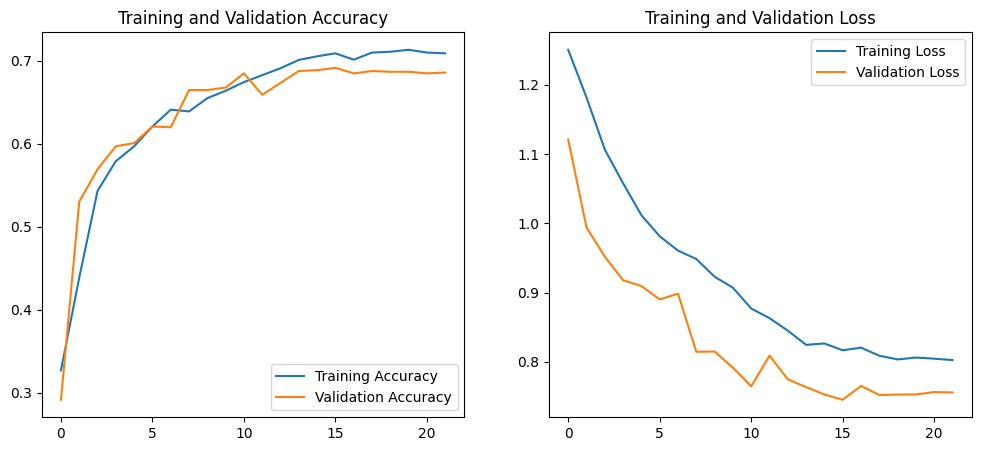

time: 220 ms (started: 2026-04-28 18:44:02 +00:00)


In [ ]:
plot_history(history_rnn)

20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step


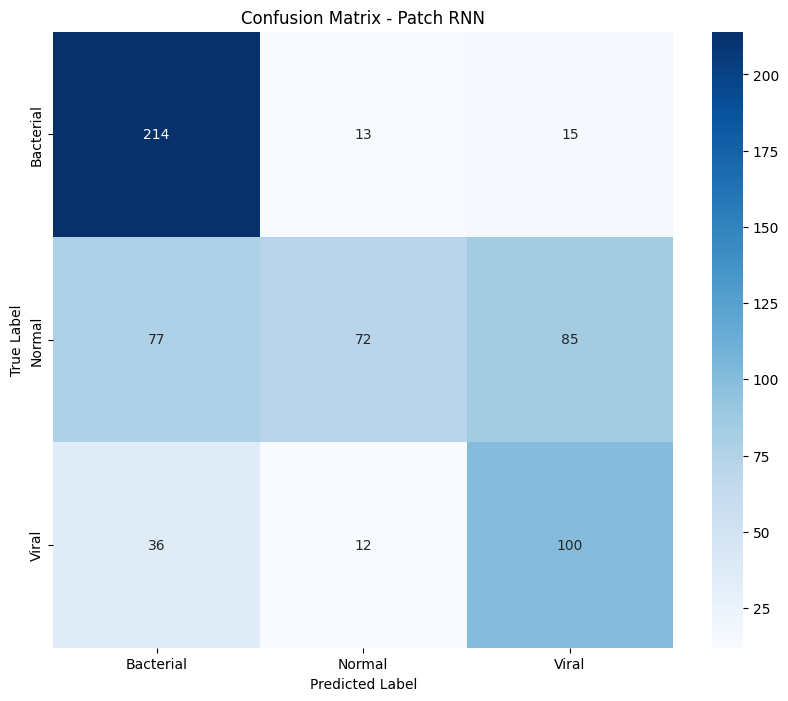


Classification Report:
              precision    recall  f1-score   support

   Bacterial       0.65      0.88      0.75       242
      Normal       0.74      0.31      0.44       234
       Viral       0.50      0.68      0.57       148

    accuracy                           0.62       624
   macro avg       0.63      0.62      0.59       624
weighted avg       0.65      0.62      0.59       624

time: 878 ms (started: 2026-04-28 18:44:02 +00:00)


In [ ]:
evaluate_rnn_model(rnn_model, X_test_patches, y_test_rnn, 'Confusion Matrix - Patch RNN')

 FINAL TEST RESULTS 
Test Loss:     1.0071
Test Accuracy: 61.86%


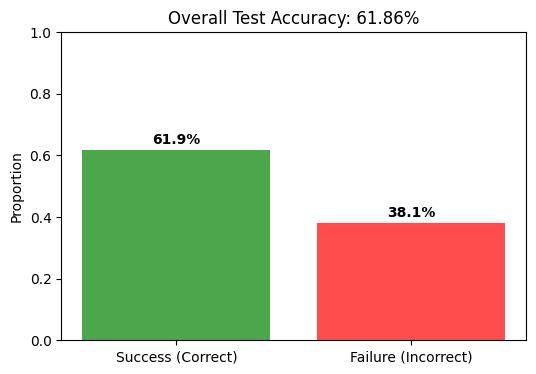

time: 466 ms (started: 2026-04-28 18:44:03 +00:00)


In [ ]:
final_test_results_rnn(X_test_patches, y_test_rnn, )

#Model Comparison
This section compares all trained models:
1. Custom CNN
2. EfficientNet (Frozen Backbone)
3. EfficientNet (Fine-tuned)
4. Patch-based RNN

The comparison includes:
 - Training & Validation Accuracy
 - Validation Loss
 - Test Accuracy (Final Performance)
 - Summary Table

##Load Saved Training Histories

In [ ]:
history_cnn_df = pd.read_csv(os.path.join(DIR_A, 'history_cnn.csv'))
history_frozen_df = pd.read_csv(os.path.join(DIR_B1, 'history_frozen.csv'))
history_finetune_df = pd.read_csv(os.path.join(DIR_B2, 'history_finetune.csv'))
history_rnn_df = pd.read_csv(os.path.join(DIR_C, 'history_rnn.csv'))

time: 5.69 s (started: 2026-04-29 17:52:08 +00:00)


##Validation Accuracy Comparison
This graph shows how well each model performs on unseen validation data


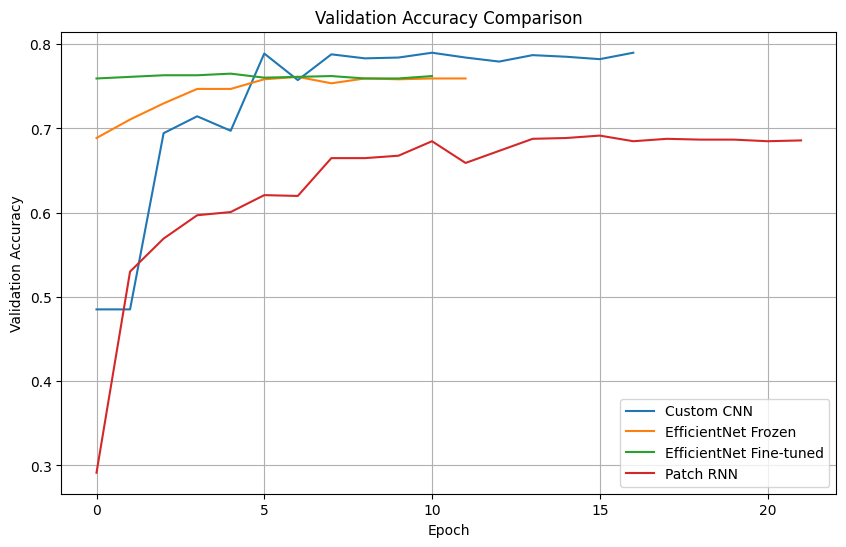

time: 727 ms (started: 2026-04-29 17:52:14 +00:00)


In [ ]:
plt.figure(figsize=(10,6))

plt.plot(history_cnn_df['val_accuracy'], label='Custom CNN')
plt.plot(history_frozen_df['val_accuracy'], label='EfficientNet Frozen')
plt.plot(history_finetune_df['val_accuracy'], label='EfficientNet Fine-tuned')
plt.plot(history_rnn_df['val_accuracy'], label='Patch RNN')

plt.title('Validation Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

##Validation Loss Comparison
This graph helps detect overfitting and training stability


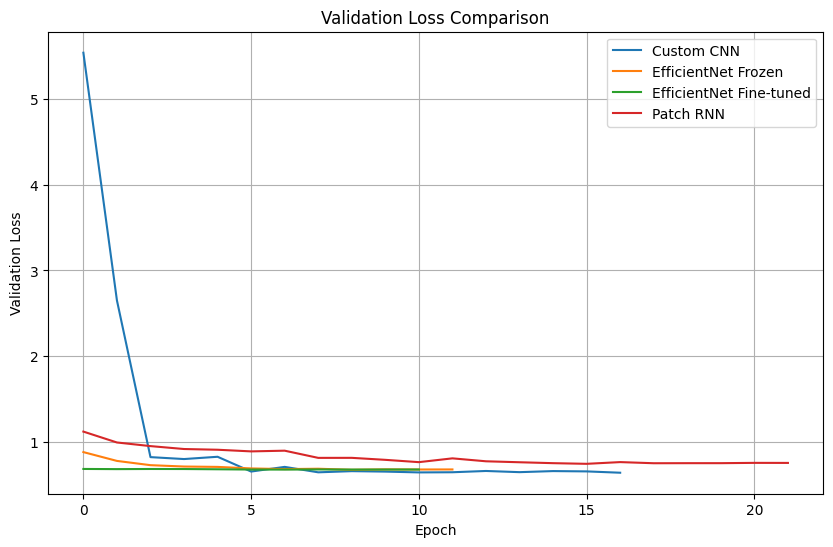

time: 726 ms (started: 2026-04-29 17:52:14 +00:00)


In [ ]:
plt.figure(figsize=(10,6))

plt.plot(history_cnn_df['val_loss'], label='Custom CNN')
plt.plot(history_frozen_df['val_loss'], label='EfficientNet Frozen')
plt.plot(history_finetune_df['val_loss'], label='EfficientNet Fine-tuned')
plt.plot(history_rnn_df['val_loss'], label='Patch RNN')

plt.title('Validation Loss Comparison')
plt.xlabel('Epoch')
plt.ylabel('Validation Loss')
plt.legend()
plt.grid(True)
plt.show()


##Training Accuracy Comparison
Show how well each model learned the training data

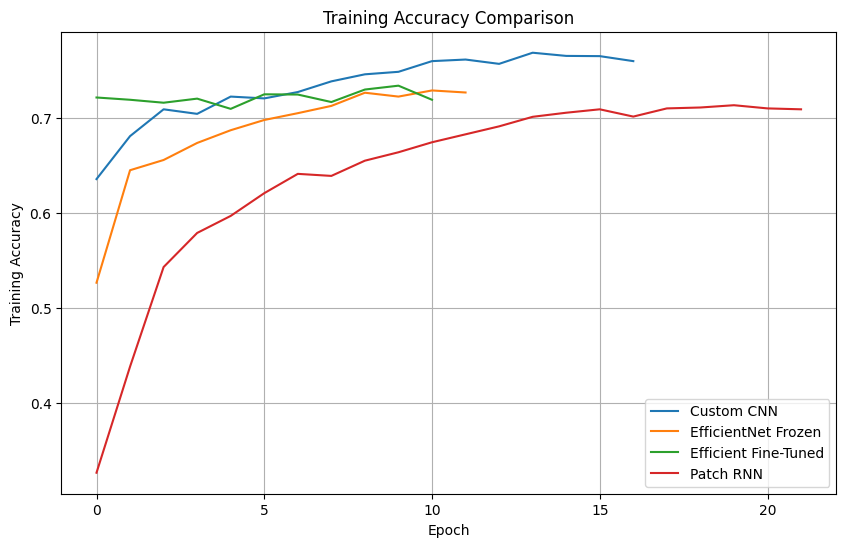

time: 757 ms (started: 2026-04-29 17:52:15 +00:00)


In [ ]:
plt.figure(figsize=(10,6))

plt.plot(history_cnn_df['accuracy'], label='Custom CNN')
plt.plot(history_frozen_df['accuracy'], label='EfficientNet Frozen'),
plt.plot(history_finetune_df['accuracy'], label='Efficient Fine-Tuned'),
plt.plot(history_rnn_df['accuracy'], label='Patch RNN')

plt.title('Training Accuracy Comparison')
plt.xlabel('Epoch')
plt.ylabel('Training Accuracy')
plt.legend()
plt.grid(True)
plt.show()

##Test Accuracy Comparison - final metric


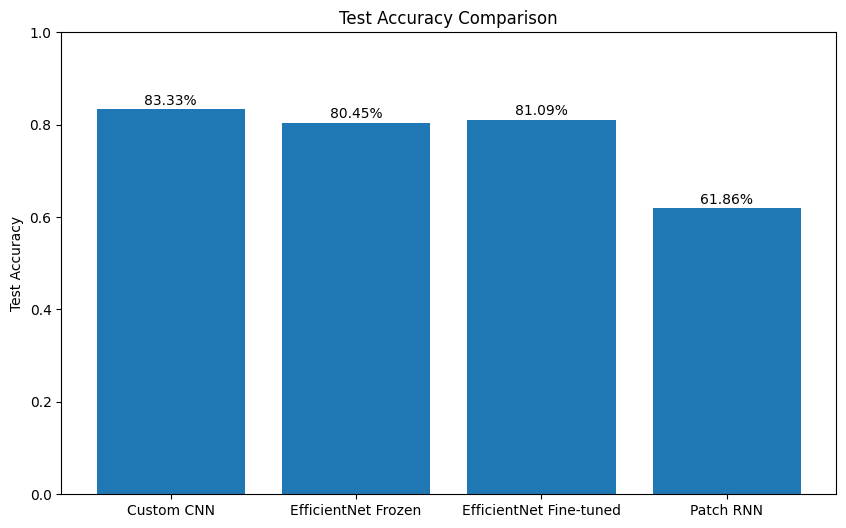

time: 523 ms (started: 2026-04-29 17:52:16 +00:00)


In [ ]:
model_names = [
    'Custom CNN',
    'EfficientNet Frozen',
    'EfficientNet Fine-tuned',
    'Patch RNN'
]

test_accuracies = [
    0.8333, #CNN
    0.8045, #Frozen
    0.8109, #Fine-tuned
    0.6186   #RNN
]

plt.figure(figsize=(10,6))
bars = plt.bar(model_names, test_accuracies)

plt.title('Test Accuracy Comparison')
plt.ylabel('Test Accuracy')
plt.ylim(0, 1)

for bar, acc in zip(bars, test_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2, acc + 0.01, f'{acc*100:.2f}%', ha='center')

plt.show()

##Summary Table
this table summarizes the perfornance of all models

In [ ]:
comparison_df = pd.DataFrame({
    'Model': model_names,

    'Best Train Accuracy': [
        history_cnn_df['accuracy'].max(),
        history_frozen_df['accuracy'].max(),
        history_finetune_df['accuracy'].max(),
        history_rnn_df['accuracy'].max()
    ],

    'Best Validation Accuracy': [
        history_cnn_df['val_accuracy'].max(),
        history_frozen_df['val_accuracy'].max(),
        history_finetune_df['val_accuracy'].max(),
        history_rnn_df['val_accuracy'].max()
    ],

    'Lowest Validation Loss': [
        history_cnn_df['val_loss'].min(),
        history_frozen_df['val_loss'].min(),
        history_finetune_df['val_loss'].min(),
        history_rnn_df['val_loss'].min()
    ],

    'Test Accuracy': test_accuracies
})

comparison_df

,Model,Best Train Accuracy,Best Validation Accuracy,Lowest Validation Loss,Test Accuracy
0,Custom CNN,0.768459,0.789876,0.641498,0.8333
1,EfficientNet Frozen,0.728793,0.761223,0.675642,0.8045
2,EfficientNet Fine-tuned,0.733811,0.765043,0.678180,0.8109
3,Patch RNN,0.713262,0.691500,0.745243,0.6186


time: 106 ms (started: 2026-04-29 17:52:17 +00:00)


##Save Comparison Table

In [ ]:
comparison_df.to_csv(
    os.path.join(DIR_COMPAR, 'model_comparison.csv'),
    index=False)

time: 649 ms (started: 2026-04-29 17:52:17 +00:00)
